# Predicting Smartphone Addiction — Playground Series S6E8

Binary classification with probabilistic output. Goal: predict `addicted_label` (probability of class 1) for each `id` in the test set.

## 1. Load the data

train.csv 691.369 - lines with features + target addicted_label
test.csv 296.302 lines with the same features but without target addicted_label
sample_submission.csv submission format model


In [1]:
import pandas as pd

df_train = pd.read_csv('../data/train.csv')
df_test = pd.read_csv('../data/test.csv')

df_train.head()


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## 2. Exploratory data analysis

Quanto tenho de nulos em cada coluna?

In [3]:
(df_train.isna().mean() * 100).sort_values(ascending=False)

social_media_hours         19.381112
gaming_hours               18.343461
weekend_screen_time        16.208855
daily_screen_time_hours    13.864376
app_opens_per_day          11.673940
notifications_per_day       9.775388
stress_level                7.976638
work_study_hours            7.451592
sleep_hours                 6.433612
academic_work_impact        6.396584
gender                      4.199494
age                         4.184307
id                          0.000000
addicted_label              0.000000
dtype: float64

são nulos ou zero horas

In [ ]:
colunas_numericas = df_train.select_dtypes(include='number').columns.drop(['id', 'addicted_label'])

for col in colunas_numericas:
    print(col)
    print('  mínimo:', df_train[col].min())
    print('  qtd de zeros:', (df_train[col] == 0).sum())
    print('  qtd de nulos:', df_train[col].isna().sum())


In [5]:
linhas_com_null = df_train.isna().any(axis=1).sum()
print(f'Linhas com pelo menos um nulo: {linhas_com_null} ({linhas_com_null / len(df_train) * 100:.1f}%)')


Linhas com pelo menos um nulo: 422184 (61.1%)


 61.1% das linhas têm pelo menos um nulo

Numéricas:


In [7]:
colunas_numericas = df_train.select_dtypes(include='number').columns.drop(['id', 'addicted_label'])

df_train[colunas_numericas].agg(['min', 'max', 'mean', 'median', 'std']).T


,min,max,mean,median,std
age,18.00,35.00,26.615408,27.00,5.153162
daily_screen_time_hours,0.50,15.00,7.640865,7.77,2.721446
social_media_hours,0.00,8.00,2.471038,2.31,1.316137
gaming_hours,0.00,4.00,1.459265,1.33,0.934552
work_study_hours,0.00,6.00,2.366971,2.20,1.258797
sleep_hours,4.50,9.00,6.804334,6.80,1.234512
notifications_per_day,20.00,250.00,145.894900,150.00,65.917556
app_opens_per_day,15.00,180.00,102.636781,104.00,48.093970
weekend_screen_time,0.51,17.56,9.479866,9.58,2.856006


In [8]:
for col in colunas_numericas:
    q1 = df_train[col].quantile(0.25)
    q3 = df_train[col].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    n_outliers = ((df_train[col] < limite_inferior) | (df_train[col] > limite_superior)).sum()
    print(f'{col}: {n_outliers} outliers ({n_outliers / len(df_train) * 100:.2f}%)')


age: 0 outliers (0.00%)
daily_screen_time_hours: 0 outliers (0.00%)
social_media_hours: 1209 outliers (0.17%)
gaming_hours: 0 outliers (0.00%)
work_study_hours: 300 outliers (0.04%)
sleep_hours: 0 outliers (0.00%)
notifications_per_day: 0 outliers (0.00%)
app_opens_per_day: 0 outliers (0.00%)
weekend_screen_time: 6 outliers (0.00%)


dentro das variáveis numéricas a quantidade de outliers é muito pequena

Categóricas:

In [9]:
colunas_categoricas = df_train.select_dtypes(include='object').columns

for col in colunas_categoricas:
    print(f'--- {col} ---')
    print(df_train[col].value_counts(dropna=False))
    print()


--- gender ---
gender
Male      223662
Female    221595
Other     217078
NaN        29034
Name: count, dtype: int64

--- stress_level ---
stress_level
High      220873
Low       207783
Medium    207565
NaN        55148
Name: count, dtype: int64

--- academic_work_impact ---
academic_work_impact
Yes    330566
No     316579
NaN     44224
Name: count, dtype: int64



C:\Users\vhbit\AppData\Local\Temp\ipykernel_28436\2301543306.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df_train.select_dtypes(include='object').columns


Numéricas vs target (boxplot comparando distribuição por classe):

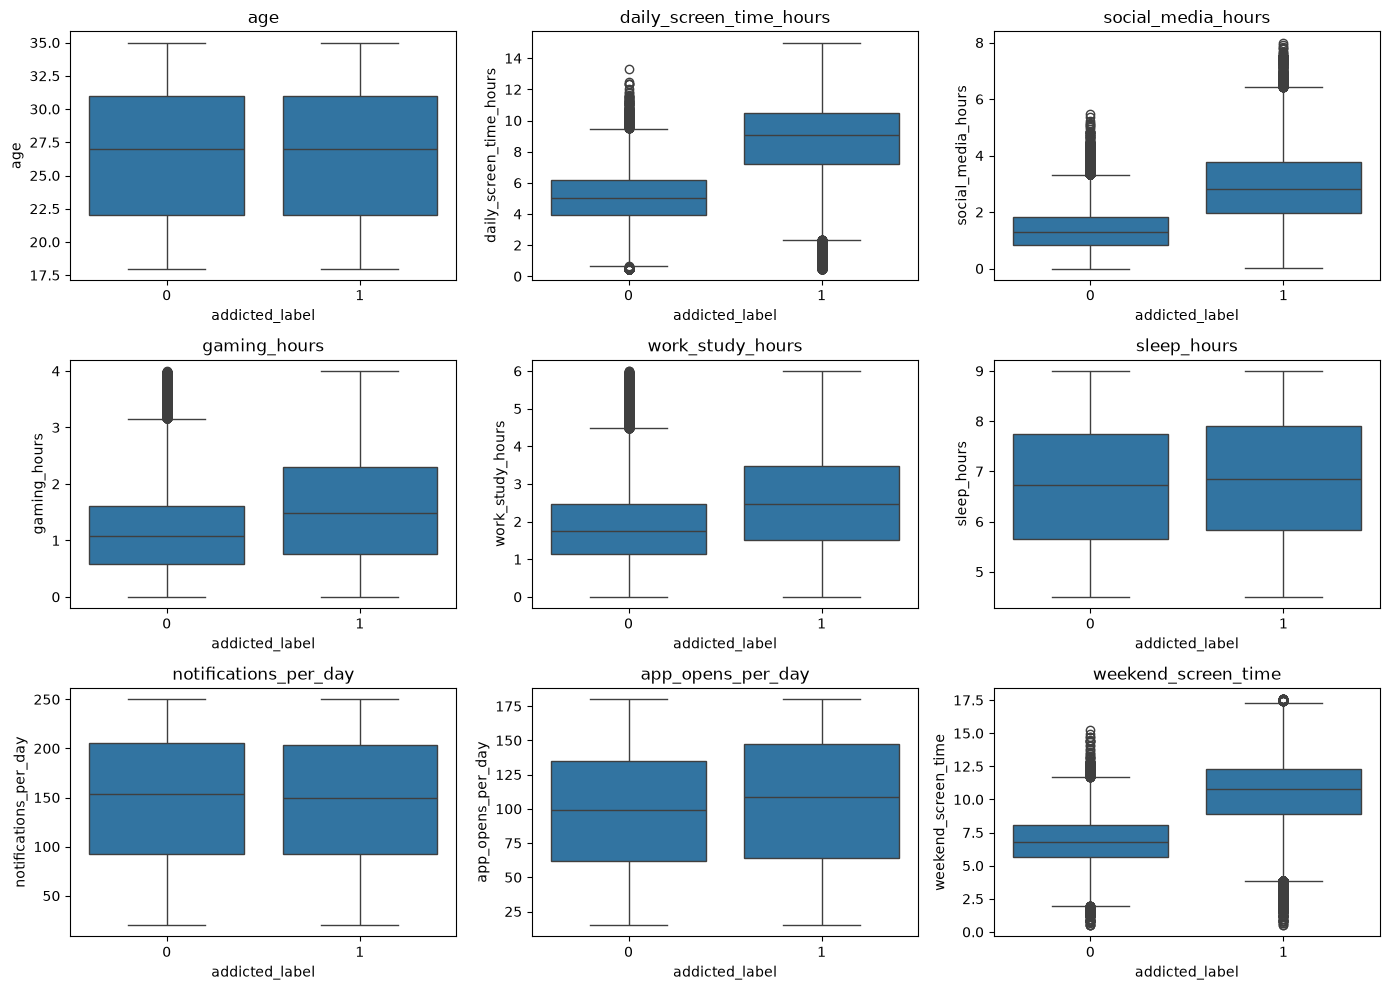

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for ax, col in zip(axes.flatten(), colunas_numericas):
    sns.boxplot(data=df_train, x='addicted_label', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


Categóricas vs target (proporção da classe 1 dentro de cada categoria):

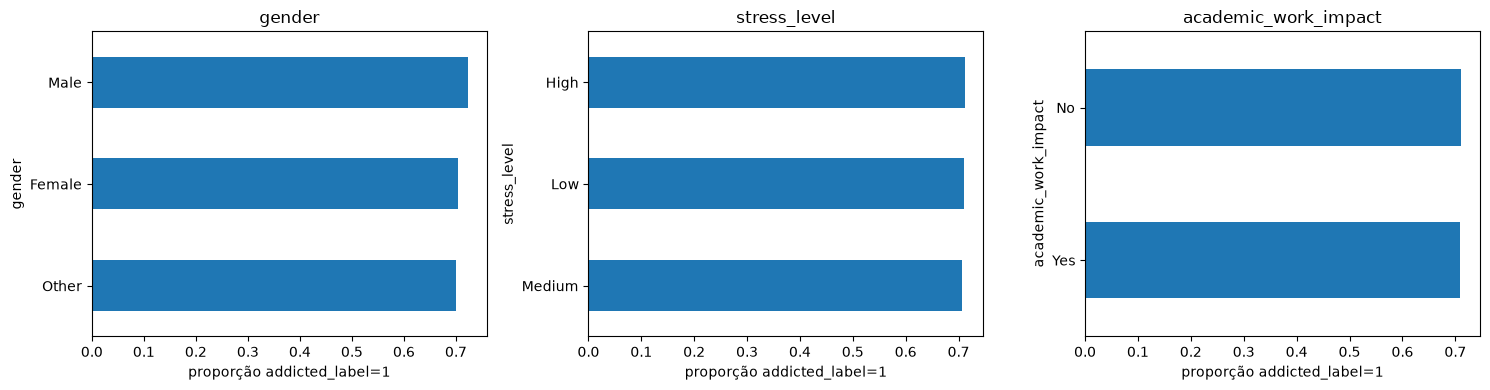

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, colunas_categoricas):
    df_train.groupby(col)['addicted_label'].mean().sort_values().plot(kind='barh', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('proporção addicted_label=1')
plt.tight_layout()
plt.show()


 o modelo provavelmente vai se apoiar quase todo em daily_screen_time_hours, weekend_screen_time e social_media_hours. As categóricas talvez nem valham a pena manter mas vou deixar o modelo decidir isso via feature importance depois, em vez de descartar às cegas agora.

PROXIMO PASSO, ANALISAR O IMPACTO DE NULOS NA VARIÁVEL TARGET E TALVEZ TENTAR ENXERGAR CORRELAÇÃO DOS VALORES NULOS

EXISTEM VALORES NULOS EM MAIS DE UMA COLUNA POR LINHA?

## 3. Split features (X) and target (y)

## 4. Train / validation / test split

## 5. Preprocessing

## 6. Baseline model

## 7. Evaluation

## 8. Generate submission